Starting training...
Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7762 - loss: 0.7010 - val_accuracy: 0.9565 - val_loss: 0.1546
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9480 - loss: 0.1777 - val_accuracy: 0.9734 - val_loss: 0.1014
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9654 - loss: 0.1131 - val_accuracy: 0.9784 - val_loss: 0.0773
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9728 - loss: 0.0867 - val_accuracy: 0.9802 - val_loss: 0.0681
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9771 - loss: 0.0742 - val_accuracy: 0.9809 - val_loss: 0.0644
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9797 - loss: 0.0645 - val_accuracy: 0.9843 - val_loss: 0.0573
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9810 - loss: 0.0579 - val_accuracy: 0.9835 - val_loss: 0.0537
Epoch 8/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9842 - loss: 0.05

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

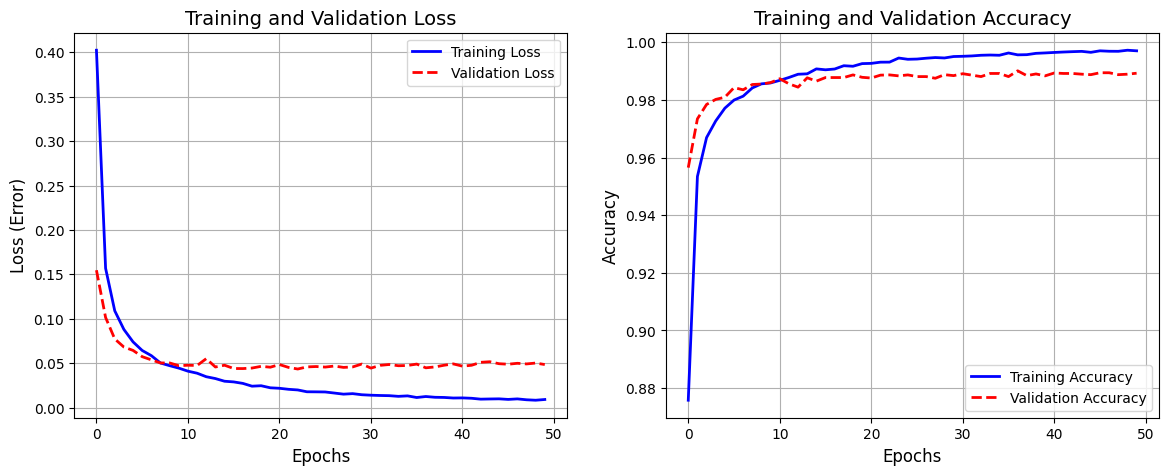

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import matplotlib.pyplot as plt

# Load and Preprocess Dataset
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.reshape((60000, 28, 28, 1)).astype('float32') / 255
x_test = x_test.reshape((10000, 28, 28, 1)).astype('float32') / 255

# Build and Compile Model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

custom_sgd = optimizers.SGD(learning_rate=0.01, momentum=0.9)

model.compile(optimizer=custom_sgd,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Training
print("Starting training...")
history = model.fit(
    x_train, y_train, 
    epochs=50, 
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# Visualize

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss function
ax1.plot(history.history['loss'], label='Training Loss', color='blue', lw=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', color='red', linestyle='--', lw=2)
ax1.set_title('Training and Validation Loss', fontsize=14)
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Loss (Error)', fontsize=12)
ax1.legend()
ax1.grid(True)

# Accuracy
ax1_acc = ax2 
ax1_acc.plot(history.history['accuracy'], label='Training Accuracy', color='blue', lw=2)
ax1_acc.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linestyle='--', lw=2)
ax1_acc.set_title('Training and Validation Accuracy', fontsize=14)
ax1_acc.set_xlabel('Epochs', fontsize=12)
ax1_acc.set_ylabel('Accuracy', fontsize=12)
ax1_acc.legend()
ax1_acc.grid(True)

# Display
plt.tight_layout